<a href="https://colab.research.google.com/github/palarunava/machine-learning-courses/blob/main/machine-learning-specialization/supervised-ml-regression-classification/C2_W1_Forward_Propagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1,2)
    X[:,1] = X[:,1] * 4 + 11.5          # 12-15 min is best
    X[:,0] = X[:,0] * (285-150) + 150  # 350-500 F (175-260 C) is best
    Y = np.zeros(len(X))

    i=0
    for t,d in X:
        y = -3/(260-175)*t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d<=y ):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return (X, Y.reshape(-1,1))

In [6]:
X, Y = load_coffee_data()

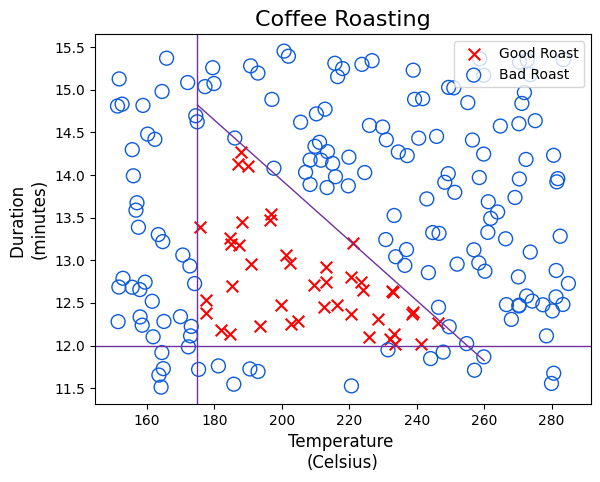

In [19]:
#@title Plot (X,Y) data
dlc = dict(dlblue = '#0096ff', dlorange = '#FF9300', dldarkred='#C00000', dlmagenta='#FF40FF', dlpurple='#7030A0', dldarkblue =  '#0D5BDC')
def plt_roast(X,Y):
    Y = Y.reshape(-1,)
    colormap = np.array(['r', 'b'])
    fig, ax = plt.subplots(1,1,)
    ax.scatter(X[Y==1,0],X[Y==1,1], s=70, marker='x', c='red', label="Good Roast" )
    ax.scatter(X[Y==0,0],X[Y==0,1], s=100, marker='o', facecolors='none',
               edgecolors=dlc["dldarkblue"],linewidth=1,  label="Bad Roast")
    tr = np.linspace(175,260,50)
    ax.plot(tr, (-3/85) * tr + 21, color=dlc["dlpurple"],linewidth=1)
    ax.axhline(y=12,color=dlc["dlpurple"],linewidth=1)
    ax.axvline(x=175,color=dlc["dlpurple"],linewidth=1)
    ax.set_title(f"Coffee Roasting", size=16)
    ax.set_xlabel("Temperature \n(Celsius)",size=12)
    ax.set_ylabel("Duration \n(minutes)",size=12)
    ax.legend(loc='upper right')
    plt.show()
plt_roast(X,Y)

Input Data:  
- Number of samples: 200  
- Number of features: 2

Input Dimension: 200 X 2

Architecture:  
Dense(3)

Let there be 3 input samples be X having 2 features each.<br>
Dimensions of X: [3 X 2]

<br>
\begin{aligned}
X &=
\begin{bmatrix}
3 & 5 \\
-1 & -3 \\
2 & -1
\end{bmatrix}
\end{aligned}
<br>

Lets define a activation layer having 4 neurons (or units).<br>
Dimensions of weights, W: [4 X 2]<br>
Dimensions of biases, b: [4 X 1]

<br>
\begin{aligned}
W &=
\begin{bmatrix}
0.2 & 0.5 \\
-1.4 & 0.3 \\
-1.2 & 1.2 \\
0.1 & 0.8
\end{bmatrix}
\qquad
b =
\begin{bmatrix}
0.3 \\
0.7 \\
1.0 \\
-0.1
\end{bmatrix}
\end{aligned}
<br>

So, the activations are calculated as follows -

<br>
\begin{aligned}
A &=
\begin{bmatrix}
3 & 5 \\
-1 & -3 \\
2 & -1
\end{bmatrix}
\end{aligned}
<br>

In [35]:
def dense(A, W, b):
    # Args:
    #     A: Activations from previous layer (Inputs in case it is the 1st layer)
    #        Dimension: m x n
    #                   m = number of samples
    #                   n = number of features
    #     W: Weights for this layer across k neurons
    #        k: number of units (or neurons) in any particular layer
    #        They are weights for each of the feature coming into the system.
    #        Dimension: n x k
    #                   n: number of input features.
    #                      Since we weigh all input features the size of the weights is equal to the number of input features.
    #                      This can also be the number of neurons from the previous layer as this act as input to the next layer.
    #                   k: number of neurons in the current layer
    #     b: Biases for this layer across k neurons
    #         k: number of units (or neurons) in any particular layer
    #         Dimension: k x 1
    return np.matmul(A, W.T) + b

In [34]:
# Weights and Bias - 1st layer
W_1 = np.array([
    [1.5, -0.7],
    [3.5, 2.0],
    [1.7, -0.5]
]) # 3 X 2

B_1 = np.array([[3.2, 4.5, 1.3]]) # 1 X 3

In [30]:
print(X[:5,:].shape)
print(W_1.T.shape)
print(X[:5,:])

(5, 2)
(2, 3)
[[185.31763812  12.69396457]
 [259.92047498  11.86766377]
 [231.01357101  14.41424211]
 [175.3666449   11.72058651]
 [187.12086467  14.12973206]]


In [32]:
np.matmul(X[:5,:], W_1.T)

array([[269.09068198, 673.99966258, 308.69300252],
       [381.57334783, 933.45698997, 435.93097558],
       [336.43038703, 837.37598273, 385.51594966],
       [254.8455568 , 637.22443018, 292.26300308],
       [270.79048456, 683.18249045, 311.0406039 ]])

In [33]:
np.matmul(X[:5,:], W_1.T) + B_1

array([[272.29068198, 678.49966258, 309.99300252],
       [384.77334783, 937.95698997, 437.23097558],
       [339.63038703, 841.87598273, 386.81594966],
       [258.0455568 , 641.72443018, 293.56300308],
       [273.99048456, 687.68249045, 312.3406039 ]])